In [31]:
import pandas as pd
import numpy as np
import sqlite3

In [32]:
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [33]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [34]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [35]:
conn = sqlite3.connect("logistics.db")

orders.to_sql("orders", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)

99224

In [36]:
query = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    r.review_score
FROM orders o
LEFT JOIN reviews r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
"""

In [37]:
logistics_df = pd.read_sql(query, conn)
logistics_df.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,5.0


In [38]:
logistics_df.head

<bound method NDFrame.head of                                order_id order_purchase_timestamp  \
0      e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   
1      53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37   
2      47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49   
3      949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   
4      ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   
...                                 ...                      ...   
97002  9c5dedf39a927c1b2549525ed64a053c      2017-03-09 09:54:05   
97003  63943bddc261676b46f01ca7ac2f7bd8      2018-02-06 12:58:58   
97004  83c1379a015df1e13d02aae0204711ab      2017-08-27 14:46:43   
97005  11c177c8e97725db2631073c19f07b62      2018-01-08 21:28:27   
97006  66dea50a8b16d9b4dee7af250b4be1a5      2018-03-08 20:57:30   

      order_delivered_customer_date  review_score  
0               2017-10-10 21:25:13           4.0  
1               2018-08-07 15:27:45           4.0

In [39]:
logistics_df['order_purchase_timestamp'] = pd.to_datetime(logistics_df['order_purchase_timestamp'])
logistics_df['order_delivered_customer_date'] = pd.to_datetime(logistics_df['order_delivered_customer_date'])

In [40]:
logistics_df['actual_delivery_days'] = (
    logistics_df['order_delivered_customer_date'] - logistics_df['order_purchase_timestamp']
).dt.days

In [41]:
logistics_df['promised_days'] = logistics_df['actual_delivery_days'] + np.random.randint(-2, 3, size=len(logistics_df))

In [42]:
logistics_df['on_time'] = (logistics_df['actual_delivery_days'] <= logistics_df['promised_days']).astype(int)

In [43]:
logistics_df['sla_breach'] = (logistics_df['on_time'] == 0).astype(int)

In [44]:
logistics_df['delivery_cost'] = np.random.uniform(20, 100, size=len(logistics_df))

In [45]:
logistics_df['csat_score'] = logistics_df['review_score']

In [46]:
logistics_df.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,review_score,actual_delivery_days,promised_days,on_time,sla_breach,delivery_cost,csat_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,4.0,8.0,7.0,0,1,92.463823,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,4.0,13.0,12.0,0,1,76.223368,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,5.0,9.0,10.0,1,0,82.120185,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,5.0,13.0,14.0,1,0,54.748625,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,5.0,2.0,1.0,0,1,35.567993,5.0


In [47]:
on_time_rate = logistics_df['on_time'].mean() * 100
print("On-Time Delivery %:", round(on_time_rate, 2))

On-Time Delivery %: 59.86


In [48]:
sla_breach_rate = logistics_df['sla_breach'].mean() * 100
print("SLA Breach %:", round(sla_breach_rate, 2))

SLA Breach %: 40.14


In [49]:
avg_delivery_time = logistics_df['actual_delivery_days'].mean()
print("Avg Delivery Days:", round(avg_delivery_time, 2))

Avg Delivery Days: 12.1


In [50]:
avg_cost = logistics_df['delivery_cost'].mean()
print("Avg Delivery Cost:", round(avg_cost, 2))

Avg Delivery Cost: 59.86


In [51]:
avg_csat = logistics_df['csat_score'].mean()
print("Avg CSAT:", round(avg_csat, 2))

Avg CSAT: 4.16


In [52]:
kpi_summary = pd.DataFrame({
    "Metric": ["On-Time %", "SLA Breach %", "Avg Delivery Days", "Avg Cost", "Avg CSAT"],
    "Value": [
        round(on_time_rate, 2),
        round(sla_breach_rate, 2),
        round(avg_delivery_time, 2),
        round(avg_cost, 2),
        round(avg_csat, 2)
    ]
})

kpi_summary

,Metric,Value
0,On-Time %,59.86
1,SLA Breach %,40.14
2,Avg Delivery Days,12.10
3,Avg Cost,59.86
4,Avg CSAT,4.16


In [53]:
logistics_df.groupby('csat_score')['on_time'].mean()

csat_score
1.0    0.593557
2.0    0.591976
3.0    0.597664
4.0    0.598304
5.0    0.600235
Name: on_time, dtype: float64

In [54]:
logistics_df.groupby('sla_breach')['delivery_cost'].mean()

sla_breach
0    59.829696
1    59.907207
Name: delivery_cost, dtype: float64

In [55]:
logistics_df.to_csv("logistics_data.csv", index=False)

In [56]:
features = logistics_df[['actual_delivery_days', 'delivery_cost']]

In [57]:
features = features.dropna()

In [59]:
features = logistics_df[['actual_delivery_days', 'delivery_cost']]

# Drop NA but KEEP index
features_clean = features.dropna()

from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)

# Fit only on clean data
anomaly_preds = model.fit_predict(features_clean)

# Create new column with default values
logistics_df['anomaly'] = 1  # assume normal

# Assign only to valid rows
logistics_df.loc[features_clean.index, 'anomaly'] = anomaly_preds

In [60]:
logistics_df['anomaly_label'] = logistics_df['anomaly'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

In [61]:
logistics_df['anomaly_label'].value_counts()

anomaly_label
Normal     92158
Anomaly     4849
Name: count, dtype: int64

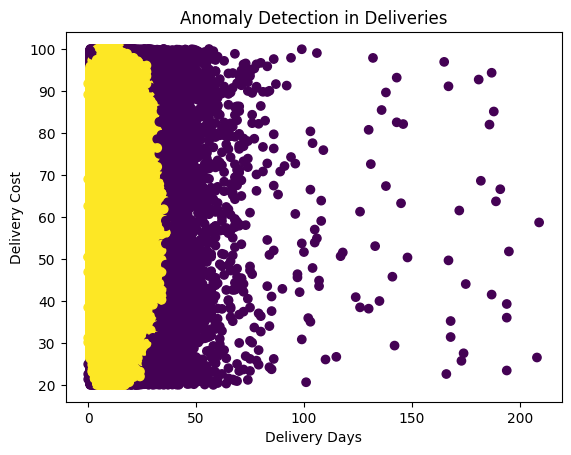

In [62]:
import matplotlib.pyplot as plt

plt.scatter(
    logistics_df['actual_delivery_days'],
    logistics_df['delivery_cost'],
    c=logistics_df['anomaly'],
)

plt.xlabel("Delivery Days")
plt.ylabel("Delivery Cost")
plt.title("Anomaly Detection in Deliveries")
plt.show()

In [63]:
logistics_df.to_csv("logistics_data_with_anomalies.csv", index=False)